In [ ]:
#MIWAF PHASE 2 - MACHINE LEARNING
# Notebook 3: Queue Time Regressor
# Description: Predict how long the queue will be at a water source based on source type, location, type of day and population served


In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from xgboost import XGBRegressor
print('All libraries imported')

All libraries imported


In [ ]:
#Load Dataset
notebook_dir = os.getcwd()
outputs_dir = os.path.join(notebook_dir, 'outputs')
models_dir = os.path.join(notebook_dir, 'models')
os.makedirs(models_dir, exist_ok=True)

#Load data
df = pd.read_csv(   
    os.path.join(outputs_dir, 'model2_queue_data.csv')
)
print(f" Shape : {df.shape}")
print(f"\n First 5 rows")
print(df.head())
print(f"\nQueue time statistics")
print(df['time_in_queue'].describe())

 Shape : (60146, 8)

 First 5 rows
   source_type_encoded  location_type_encoded  province_encoded  \
0                    0                      1                 4   
1                    4                      0                 3   
2                    1                      0                 2   
3                    4                      1                 0   
4                    1                      0                 0   

   number_of_people_served  hour  day_of_week  is_weekend  time_in_queue  
0                      402     9            4           0             15  
1                      252     9            4           0              0  
2                      542     9            4           0             62  
3                      210     9            4           0              0  
4                     2598    10            4           0             28  

Queue time statistics
count    60146.000000
mean        60.745469
std         92.207404
min          0.000000
2

In [7]:
#Features and Target - Separate inputs from target
#X - what the model learns from
X = df[[
    'source_type_encoded',
    'location_type_encoded',
    'province_encoded',
    'number_of_people_served',
    'hour',
    'day_of_week',
    'is_weekend'
]]
#y = the number we want to predict (Queue time in minutes)
y = df['time_in_queue']
print(f" Features and target separated")
print(f" X shape : {X.shape}")
print(f" y shape: {y.shape}")
print(f"\nFeatures used:")
for col in X.columns:
    print(f" {col} ")
print(f"\nTarget: time_in_queue")
print(f" Min : {y.min()} minutes")
print(f" Max : {y.max()} minutes")
print(f" Mean : {y.mean():.2f} minutes")

 Features and target separated
 X shape : (60146, 7)
 y shape: (60146,)

Features used:
 source_type_encoded 
 location_type_encoded 
 province_encoded 
 number_of_people_served 
 hour 
 day_of_week 
 is_weekend 

Target: time_in_queue
 Min : 0 minutes
 Max : 539 minutes
 Mean : 60.75 minutes


In [10]:
#Train Test Split - Split 80% training / 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
print(f" Training set : {X_train.shape[0]} rows(80%)")
print(f" Testing set : {X_test.shape[0]} rows (20%)")
print(f"\nAverage queue time in training set : " f" {y_train.mean():.2f}mins")
print(f"Average queue time in testing set : " f"{y_test.mean():.2f}mins")

 Training set : 48116 rows(80%)
 Testing set : 12030 rows (20%)

Average queue time in training set :  60.60mins
Average queue time in testing set : 61.31mins


In [12]:
#Scale Features to same range
scaler_q = StandardScaler()

X_train_scaled = scaler_q.fit_transform(X_train)
X_test_scaled = scaler_q.transform(X_test)

with open(
    os.path.join(models_dir, 'scaler_queue.pkl'), 'wb'
) as f:
    pickle.dump(scaler_q, f)

In [15]:
#Train Model Linear Regression
print('Train using Linear Regression Model')

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

#Evaluation metrics for regression
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)
print(f" MAE : {lr_mae:.2f} mins" f" average prediction error")
print(f" RMSE: {lr_rmse:.2f}mins" f" punishes large errors more")
print(f" R² : {lr_r2:.4f}" f" 1.0 = perfect, 0 = random")


Train using Linear Regression Model
 MAE : 34.72 mins average prediction error
 RMSE: 53.36mins punishes large errors more
 R² : 0.6638 1.0 = perfect, 0 = random


In [18]:
#Model 2 Random Forest 
print("Training using random forest algorithm")
rf_model = RandomForestRegressor(
    n_estimators= 100,
    random_state= 42,
    n_jobs= -1 
)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2   = r2_score(y_test, rf_predictions)
print(f" MAE: {rf_mae:.2f}mins")
print(f" RMSE : {rf_rmse:.2f}mins")
print(f" R² : {rf_r2}:.4f")

Training using random forest algorithm
 MAE: 21.41mins
 RMSE : 43.34mins
 R² : 0.7782605627250019:.4f


In [20]:
#Training using XGBoost
print(f" Training using XGBoost algorithm")
xgb_model = XGBRegressor( n_estimators = 100, random_state = 42, versobility = 0)
xgb_model.fit(X_train_scaled, y_train)
xgb_predictions = xgb_model.predict(X_test_scaled)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f" MAE : {xgb_mae:.2f} mins")
print(f" RMSE : {xgb_rmse:.2f} mins")
print(f" R²: {xgb_r2:.4f}")

 Training using XGBoost algorithm
 MAE : 21.05 mins
 RMSE : 41.89 mins
 R²: 0.7929


In [23]:
#Compare the 3 models 
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE (mins)' : [lr_mae, rf_mae, xgb_mae],
    'RMSE (mins)' : [lr_rmse, rf_rmse, xgb_rmse],
    'R² Score' : [lr_r2, rf_r2, xgb_r2]
})
results['MAE (mins)'] = results['MAE (mins)'].round(2)
results['RMSE (mins)'] = results['RMSE (mins)'].round(2)
results['R² Score'] = results['R² Score'].round(4)

#Best model = lowest MAE
results = results.sort_values('MAE (mins)', ascending=True)

print("=" * 55)
print( " MODEL COMPARISION - QUEUE TIME REGRESSOR")
print("=" * 55)
print(f" Best Model: {results.iloc[0]['Model']}")
print(f" MAE : {results.iloc[0]['MAE (mins)']}mins " f" average error") 
print(f" R²: {results.iloc[0]['R² Score']}" f" accuracy score")


 MODEL COMPARISION - QUEUE TIME REGRESSOR
 Best Model: XGBoost
 MAE : 21.05mins  average error
 R²: 0.7929 accuracy score


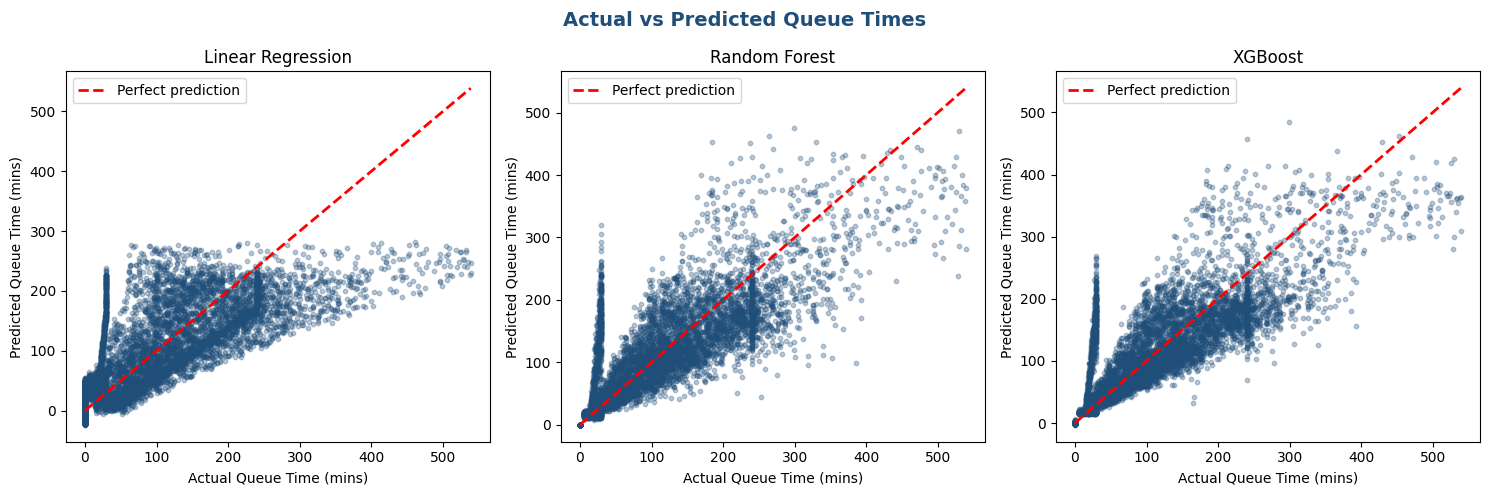

In [25]:
# Chart: Actual vs Predicted queue times

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Actual vs Predicted Queue Times',
    fontsize=14, fontweight='bold', color='#1F4E79'
)

models_list = [
    ('Linear Regression', lr_predictions),
    ('Random Forest',     rf_predictions),
    ('XGBoost',           xgb_predictions)
]

for ax, (name, preds) in zip(axes, models_list):
    ax.scatter(
        y_test, preds,
        alpha=0.3, color='#1F4E79', s=10
    )
    # Perfect prediction line
    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Perfect prediction'
    )
    ax.set_xlabel('Actual Queue Time (mins)')
    ax.set_ylabel('Predicted Queue Time (mins)')
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.savefig(
    os.path.join(outputs_dir, 'queue_actual_vs_predicted.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()

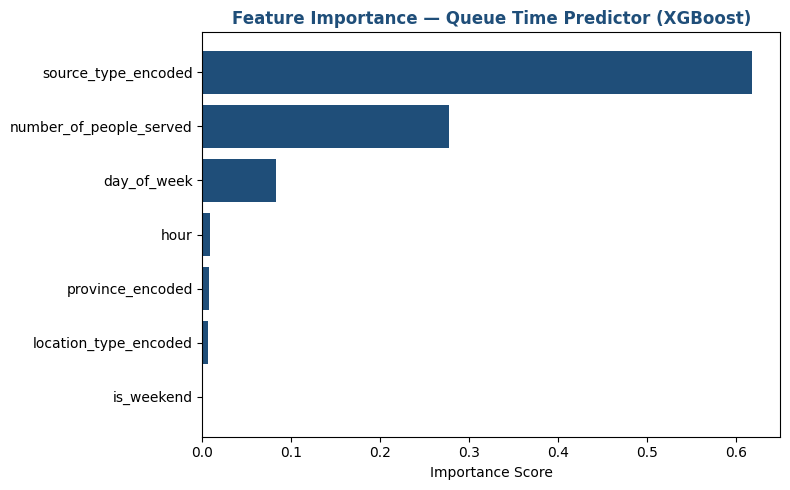

In [27]:
# Which features matter most for predicting queue time?

feature_names = [
    'source_type_encoded',
    'location_type_encoded',
    'province_encoded',
    'number_of_people_served',
    'hour',
    'day_of_week',
    'is_weekend'
]

# Get feature importance from XGBoost
importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color='#1F4E79'
)
plt.title(
    'Feature Importance — Queue Time Predictor (XGBoost)',
    fontweight='bold', color='#1F4E79'
)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(
    os.path.join(outputs_dir, 'queue_feature_importance.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()

In [29]:
# Save best model for Streamlit app

best_mae = min(lr_mae, rf_mae, xgb_mae)

if best_mae == xgb_mae:
    best_model      = xgb_model
    best_model_name = 'XGBoost'
elif best_mae == rf_mae:
    best_model      = rf_model
    best_model_name = 'Random Forest'
else:
    best_model      = lr_model
    best_model_name = 'Linear Regression'

with open(
    os.path.join(models_dir, 'queue_model.pkl'), 'wb'
) as f:
    pickle.dump(best_model, f)

print(f"   Model : {best_model_name}")
print(f"   MAE   : {best_mae:.2f} mins average error")
print(f"   Saved : models/queue_model.pkl")

   Model : XGBoost
   MAE   : 21.05 mins average error
   Saved : models/queue_model.pkl
